# Analisis canasta SEPA

In [2]:
# ============================================================
# CELDA 1 — Imports y configuración
# ============================================================
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Rutas en Colab
INPUT_DIR = "/content"
OUTPUT_FILE = "/content/canasta_SEPA_consolidado.xlsx"
IPC_FILE = "/content/IPC.xlsx"

# Archivos esperados (todos los semestres procesados)
SEMESTRES = ["2022A","2022B","2023A","2023B","2024A","2024B","2025A","2025B","2026A"]

# >>> FILTRO PRINCIPAL: análisis a partir de este mes inclusive
MES_INICIO = '2023-05'

# Meses específicos a anular variación mensual (panel inestable en 2023A)
# may-23: primer mes válido pero su variación vs el mes previo no es comparable
# jun-23: el panel todavía se estaba estabilizando
MESES_VARIACION_NO_VALIDA = ['2023-05', '2023-06']

print("Archivos esperados:")
for s in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{s}_serie.xlsx"
    if os.path.exists(path):
        print(f"  ✅ canasta_{s}_serie.xlsx  ({os.path.getsize(path)/1024:.0f} KB)")
    else:
        print(f"  ⚠️ NO ENCONTRADO: canasta_{s}_serie.xlsx (se saltea)")

print(f"\nIPC INDEC:")
if os.path.exists(IPC_FILE):
    print(f"  ✅ IPC.xlsx  ({os.path.getsize(IPC_FILE)/1024:.0f} KB)")
else:
    print(f"  ❌ NO ENCONTRADO: IPC.xlsx")

print(f"\n📅 Análisis a partir de: {MES_INICIO} (inclusive)")
print(f"📅 Variaciones mensuales no calculadas para: {MESES_VARIACION_NO_VALIDA}")

Archivos esperados:
  ✅ canasta_2022A_serie.xlsx  (126 KB)
  ✅ canasta_2022B_serie.xlsx  (130 KB)
  ✅ canasta_2023A_serie.xlsx  (157 KB)
  ✅ canasta_2023B_serie.xlsx  (217 KB)
  ✅ canasta_2024A_serie.xlsx  (239 KB)
  ✅ canasta_2024B_serie.xlsx  (229 KB)
  ✅ canasta_2025A_serie.xlsx  (225 KB)
  ✅ canasta_2025B_serie.xlsx  (229 KB)
  ✅ canasta_2026A_serie.xlsx  (154 KB)

IPC INDEC:
  ✅ IPC.xlsx  (24 KB)

📅 Análisis a partir de: 2023-05 (inclusive)
📅 Variaciones mensuales no calculadas para: ['2023-05', '2023-06']


In [3]:
# ============================================================
# CELDA 2 — Consolidar canasta nacional ponderada
# ============================================================
serie_nacional = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        print(f"⚠️ Salteando {sem} (archivo no encontrado)")
        continue

    df = pd.read_excel(path, sheet_name='canasta_nacional_ponderada')
    df['semestre'] = sem
    serie_nacional.append(df)
    print(f"  {sem}: {len(df)} meses cargados")

serie_nacional = pd.concat(serie_nacional, ignore_index=True)
serie_nacional = serie_nacional.sort_values('mes').reset_index(drop=True)

# FILTRAR a partir del mes de inicio
serie_nacional_valida = serie_nacional[serie_nacional['mes'] >= MES_INICIO].copy()
serie_nacional_valida = serie_nacional_valida.sort_values('mes').reset_index(drop=True)

# Recalcular variación mensual sobre la serie ya filtrada
serie_nacional_valida['variacion_mensual_%'] = (
    serie_nacional_valida['canasta_nacional_ponderada'].pct_change() * 100
).round(2)

# Anular variaciones no comparables (may-23 y jun-23)
for mes in MESES_VARIACION_NO_VALIDA:
    serie_nacional_valida.loc[serie_nacional_valida['mes'] == mes, 'variacion_mensual_%'] = np.nan

# Construir índice base 100 sobre el primer mes válido (mayo 2023 = 100)
base = serie_nacional_valida['canasta_nacional_ponderada'].iloc[0]
serie_nacional_valida['indice_canasta_base100'] = (
    serie_nacional_valida['canasta_nacional_ponderada'] / base * 100
).round(2)

print(f"\n✅ Serie consolidada: {len(serie_nacional)} meses totales en los archivos")
print(f"   Período analizado: {MES_INICIO} en adelante")
print(f"   Meses válidos: {len(serie_nacional_valida)}")
print(f"\nPrimer mes (base 100): {serie_nacional_valida['mes'].iloc[0]}")
print(f"Último mes: {serie_nacional_valida['mes'].iloc[-1]}")
print(f"\nMuestra (primeros 5 meses):")
print(serie_nacional_valida[['mes','canasta_nacional_ponderada','variacion_mensual_%','indice_canasta_base100']].head().to_string(index=False))

  2022A: 6 meses cargados
  2022B: 6 meses cargados
  2023A: 6 meses cargados
  2023B: 6 meses cargados
  2024A: 6 meses cargados
  2024B: 6 meses cargados
  2025A: 6 meses cargados
  2025B: 6 meses cargados
  2026A: 4 meses cargados

✅ Serie consolidada: 52 meses totales en los archivos
   Período analizado: 2023-05 en adelante
   Meses válidos: 36

Primer mes (base 100): 2023-05
Último mes: 2026-04

Muestra (primeros 5 meses):
    mes  canasta_nacional_ponderada  variacion_mensual_%  indice_canasta_base100
2023-05                    30844.90                  NaN                  100.00
2023-06                    37566.93                  NaN                  121.79
2023-07                    39565.57                 5.32                  128.27
2023-08                    46505.97                17.54                  150.77
2023-09                    55480.99                19.30                  179.87


In [4]:
# ============================================================
# CELDA 3 — Consolidar canasta mensual por provincia
# ============================================================
serie_provincia = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        continue
    df = pd.read_excel(path, sheet_name='canasta_mes_provincia')
    df['semestre'] = sem
    serie_provincia.append(df)

serie_provincia = pd.concat(serie_provincia, ignore_index=True)
serie_provincia_valida = serie_provincia[serie_provincia['mes'] >= MES_INICIO].copy()
serie_provincia_valida = serie_provincia_valida.sort_values(['mes','provincia']).reset_index(drop=True)

print(f"✅ Serie por provincia: {len(serie_provincia_valida):,} filas")
print(f"   Provincias: {serie_provincia_valida['provincia'].nunique()}")
print(f"   Meses: {serie_provincia_valida['mes'].nunique()}")

✅ Serie por provincia: 864 filas
   Provincias: 24
   Meses: 36


In [5]:
# ============================================================
# CELDA 4 — Consolidar canasta mensual por región
# ============================================================
serie_region = []

for sem in SEMESTRES:
    path = f"{INPUT_DIR}/canasta_{sem}_serie.xlsx"
    if not os.path.exists(path):
        continue
    df = pd.read_excel(path, sheet_name='canasta_mes_region')
    df['semestre'] = sem
    serie_region.append(df)

serie_region = pd.concat(serie_region, ignore_index=True)
serie_region_valida = serie_region[serie_region['mes'] >= MES_INICIO].copy()
serie_region_valida = serie_region_valida.sort_values(['mes','region']).reset_index(drop=True)

print(f"✅ Serie por región: {len(serie_region_valida):,} filas")
print(f"   Regiones: {serie_region_valida['region'].nunique()}")
print(f"   Meses: {serie_region_valida['mes'].nunique()}")

✅ Serie por región: 216 filas
   Regiones: 6
   Meses: 36


In [6]:
# ============================================================
# CELDA 5 — Cargar y procesar IPC INDEC
# ============================================================
ipc_raw = pd.read_excel(IPC_FILE)
print(f"IPC INDEC cargado: {len(ipc_raw)} filas")

# La columna 'date' viene como datetime → convertir a string formato 'YYYY-MM'
ipc_raw['date'] = pd.to_datetime(ipc_raw['date'])
ipc_raw['mes'] = ipc_raw['date'].dt.strftime('%Y-%m')

# Renombrar columnas largas a códigos más cómodos
ipc_raw = ipc_raw.rename(columns={
    'Nivel general': 'ipc_general',
    'Alimentos y bebidas no alcohólicas': 'ipc_alimentos',
    'Bebidas Alcohólicas y tabaco': 'ipc_bebidas_alc',
    'Prendas de vestir y calzado': 'ipc_vestir',
    'Vivienda, agua, electricidad, gas y otros combustibles': 'ipc_vivienda',
    'Equipo y mantenimiento del hogar': 'ipc_hogar',
    'Salud': 'ipc_salud',
    'Transporte': 'ipc_transporte',
    'Comunicación': 'ipc_comunicacion',
    'Recreación y cultura': 'ipc_recreacion',
    'Educación': 'ipc_educacion',
    'Restaurantes y hoteles': 'ipc_restaurantes',
    'Bienes y servicios varios': 'ipc_otros',
})

ipc = ipc_raw[['mes','ipc_general','ipc_alimentos','ipc_bebidas_alc',
               'ipc_vestir','ipc_vivienda','ipc_hogar','ipc_salud',
               'ipc_transporte','ipc_comunicacion','ipc_recreacion',
               'ipc_educacion','ipc_restaurantes','ipc_otros']].copy()

# Asegurar numérico
for c in ipc.columns:
    if c != 'mes':
        ipc[c] = pd.to_numeric(
            ipc[c].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

# Filtrar IPC a meses con datos publicados (descartar filas vacías a futuro)
ipc = ipc.dropna(subset=['ipc_general']).copy()
ipc = ipc.sort_values('mes').reset_index(drop=True)

# Variaciones mensuales del IPC (fill_method=None para no rellenar NaN)
ipc['ipc_general_var_%'] = (ipc['ipc_general'].pct_change(fill_method=None) * 100).round(2)
ipc['ipc_alimentos_var_%'] = (ipc['ipc_alimentos'].pct_change(fill_method=None) * 100).round(2)

print(f"✅ IPC procesado: {len(ipc)} meses con dato publicado")
print(f"   Período: {ipc['mes'].min()} a {ipc['mes'].max()}")
print(f"\nMuestra (últimos 12 meses publicados):")
print(ipc[['mes','ipc_general','ipc_general_var_%','ipc_alimentos','ipc_alimentos_var_%']].tail(12).to_string(index=False))

IPC INDEC cargado: 121 filas
✅ IPC procesado: 111 meses con dato publicado
   Período: 2017-01 a 2026-03

Muestra (últimos 12 meses publicados):
    mes  ipc_general  ipc_general_var_%  ipc_alimentos  ipc_alimentos_var_%
2025-04    8585.6080               2.78      9318.2090                 2.95
2025-05    8714.4870               1.50      9365.3120                 0.51
2025-06    8855.5680               1.62      9418.0830                 0.56
2025-07    9023.9730               1.90      9596.7410                 1.90
2025-08    9193.2440               1.88      9729.0210                 1.38
2025-09    9384.0920               2.08      9910.1310                 1.86
2025-10    9603.8620               2.34     10136.6610                 2.29
2025-11    9841.3580               2.47     10421.9130                 2.81
2025-12   10121.3715               2.85     10748.4071                 3.13
2026-01   10413.0309               2.88     11251.1166                 4.68
2026-02   10714.625

In [7]:
# ============================================================
# CELDA 6 — Construir tabla comparativa SEPA vs IPC
# ============================================================
# Merge de serie nacional válida con IPC
comparativa = serie_nacional_valida.merge(
    ipc[['mes','ipc_general','ipc_general_var_%','ipc_alimentos','ipc_alimentos_var_%']],
    on='mes', how='left'
)

# Reindexar IPC con base en el primer mes válido (mayo 2023 = 100)
ipc_base = comparativa['ipc_general'].iloc[0]
comparativa['indice_ipc_general_base100'] = (comparativa['ipc_general'] / ipc_base * 100).round(2)

ipc_alim_base = comparativa['ipc_alimentos'].iloc[0]
comparativa['indice_ipc_alimentos_base100'] = (comparativa['ipc_alimentos'] / ipc_alim_base * 100).round(2)

# Brechas (canasta - IPC) en puntos porcentuales
comparativa['brecha_var_vs_ipc_general_pp'] = (
    comparativa['variacion_mensual_%'] - comparativa['ipc_general_var_%']
).round(2)
comparativa['brecha_var_vs_ipc_alimentos_pp'] = (
    comparativa['variacion_mensual_%'] - comparativa['ipc_alimentos_var_%']
).round(2)
comparativa['brecha_acumulada_vs_ipc_general_pp'] = (
    comparativa['indice_canasta_base100'] - comparativa['indice_ipc_general_base100']
).round(2)
comparativa['brecha_acumulada_vs_ipc_alimentos_pp'] = (
    comparativa['indice_canasta_base100'] - comparativa['indice_ipc_alimentos_base100']
).round(2)

print(f"✅ Comparativa generada: {len(comparativa)} meses\n")
print("=== RESUMEN: PRIMEROS Y ÚLTIMOS 5 MESES ===")
cols_resumen = ['mes','canasta_nacional_ponderada','variacion_mensual_%',
                'ipc_general_var_%','ipc_alimentos_var_%',
                'indice_canasta_base100','indice_ipc_general_base100','indice_ipc_alimentos_base100']
print("\n--- Primeros 5 meses ---")
print(comparativa[cols_resumen].head().to_string(index=False))
print("\n--- Últimos 5 meses ---")
print(comparativa[cols_resumen].tail().to_string(index=False))

✅ Comparativa generada: 36 meses

=== RESUMEN: PRIMEROS Y ÚLTIMOS 5 MESES ===

--- Primeros 5 meses ---
    mes  canasta_nacional_ponderada  variacion_mensual_%  ipc_general_var_%  ipc_alimentos_var_%  indice_canasta_base100  indice_ipc_general_base100  indice_ipc_alimentos_base100
2023-05                    30844.90                  NaN               7.77                 5.81                  100.00                      100.00                        100.00
2023-06                    37566.93                  NaN               5.95                 4.15                  121.79                      105.95                        104.15
2023-07                    39565.57                 5.32               6.34                 5.76                  128.27                      112.67                        110.15
2023-08                    46505.97                17.54              12.44                15.59                  150.77                      126.69                        127.32
2

In [8]:
# ============================================================
# CELDA 7 — Exportar Excel consolidado y descargar
# ============================================================
with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as w:
    serie_nacional_valida.to_excel(w, sheet_name='nacional_valida', index=False)
    serie_nacional.to_excel(w, sheet_name='nacional_completa', index=False)
    serie_provincia_valida.to_excel(w, sheet_name='por_provincia', index=False)
    serie_region_valida.to_excel(w, sheet_name='por_region', index=False)
    ipc.to_excel(w, sheet_name='ipc_indec', index=False)
    comparativa.to_excel(w, sheet_name='comparativa_sepa_ipc', index=False)

    notas = pd.DataFrame({
        'campo': [
            'Fuente datos SEPA',
            'Fuente IPC',
            'Productos en canasta',
            'Provincias',
            'Regiones',
            'Período de análisis',
            'Meses con variación no calculable',
            'Razón',
            'Mes base índices',
            'Población ponderación',
        ],
        'valor': [
            'Ministerio de Economía - Sistema Electrónico de Publicidad de Precios Argentinos (SEPA)',
            'INDEC - Índice de Precios al Consumidor (IPC)',
            '30 productos de consumo masivo (Lácteos, Almacén, Bebidas, Limpieza, Higiene, Snacks)',
            f'{serie_provincia_valida["provincia"].nunique()} jurisdicciones',
            f'{serie_region_valida["region"].nunique()} regiones (AMBA, Pampeana, NOA, NEA, Cuyo, Patagonia)',
            f'Desde {serie_nacional_valida["mes"].iloc[0]} (mayo 2023) hasta {serie_nacional_valida["mes"].iloc[-1]}',
            ', '.join(MESES_VARIACION_NO_VALIDA),
            'Cobertura SEPA en proceso de estabilización tras ampliación del panel de cadenas reportantes',
            f'{serie_nacional_valida["mes"].iloc[0]} = 100',
            'Censo INDEC 2022 (45.892.285 habitantes en las 24 jurisdicciones)',
        ]
    })
    notas.to_excel(w, sheet_name='metodologia', index=False)

print(f"✅ Archivo consolidado: {OUTPUT_FILE}")
print(f"   Tamaño: {os.path.getsize(OUTPUT_FILE)/1024:.0f} KB")

from google.colab import files
files.download(OUTPUT_FILE)

✅ Archivo consolidado: /content/canasta_SEPA_consolidado.xlsx
   Tamaño: 60 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

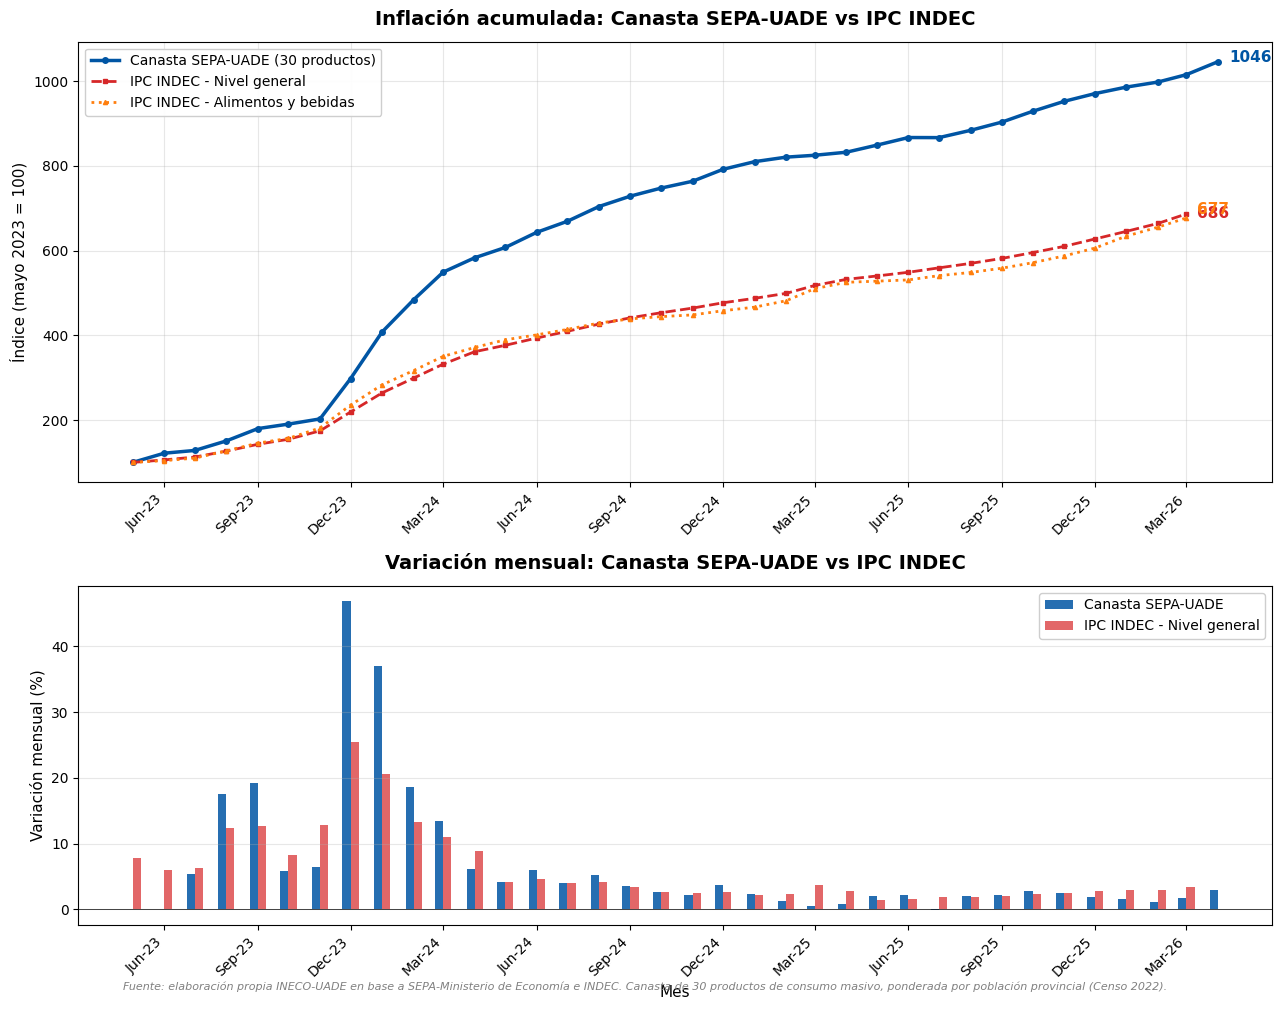


✅ Gráfico guardado en: /content/grafico_canasta_vs_ipc.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ============================================================
# CELDA 8 — Gráficos comparativos canasta SEPA vs IPC
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Colores institucionales
COLOR_CANASTA = '#0055A4'   # azul UADE
COLOR_IPC_GEN = '#D62728'   # rojo
COLOR_IPC_ALI = '#FF7F0E'   # naranja

# Preparar fechas
df_plot = comparativa.copy()
df_plot['fecha'] = pd.to_datetime(df_plot['mes'] + '-01')
df_plot = df_plot.sort_values('fecha').reset_index(drop=True)

# Crear figura con 2 paneles
fig, axes = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [1.3, 1]})

# ============ PANEL 1: ÍNDICES BASE 100 ============
ax1 = axes[0]
ax1.plot(df_plot['fecha'], df_plot['indice_canasta_base100'],
         color=COLOR_CANASTA, linewidth=2.5,
         label='Canasta SEPA-UADE (30 productos)',
         marker='o', markersize=4)
ax1.plot(df_plot['fecha'], df_plot['indice_ipc_general_base100'],
         color=COLOR_IPC_GEN, linewidth=2,
         label='IPC INDEC - Nivel general',
         linestyle='--', marker='s', markersize=3)
ax1.plot(df_plot['fecha'], df_plot['indice_ipc_alimentos_base100'],
         color=COLOR_IPC_ALI, linewidth=2,
         label='IPC INDEC - Alimentos y bebidas',
         linestyle=':', marker='^', markersize=3)

ax1.set_title('Inflación acumulada: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Índice (mayo 2023 = 100)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Anotar valor final de la canasta (siempre disponible)
ultimo = df_plot.iloc[-1]
ax1.annotate(f"{ultimo['indice_canasta_base100']:.0f}",
             xy=(ultimo['fecha'], ultimo['indice_canasta_base100']),
             xytext=(8, 0), textcoords='offset points',
             color=COLOR_CANASTA, fontweight='bold', fontsize=11)

# Anotar último valor publicado de IPC (último mes con datos no nulos)
ipc_ultimo = df_plot.dropna(subset=['indice_ipc_general_base100']).iloc[-1]
ax1.annotate(f"{ipc_ultimo['indice_ipc_general_base100']:.0f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['indice_ipc_general_base100']),
             xytext=(8, -3), textcoords='offset points',
             color=COLOR_IPC_GEN, fontweight='bold', fontsize=11)
ax1.annotate(f"{ipc_ultimo['indice_ipc_alimentos_base100']:.0f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['indice_ipc_alimentos_base100']),
             xytext=(8, 3), textcoords='offset points',
             color=COLOR_IPC_ALI, fontweight='bold', fontsize=11)

# ============ PANEL 2: VARIACIONES MENSUALES ============
ax2 = axes[1]
x = df_plot['fecha']
width = pd.Timedelta(days=8)

ax2.bar(x - width/2, df_plot['variacion_mensual_%'], width=width,
        color=COLOR_CANASTA, alpha=0.85, label='Canasta SEPA-UADE')
ax2.bar(x + width/2, df_plot['ipc_general_var_%'], width=width,
        color=COLOR_IPC_GEN, alpha=0.7, label='IPC INDEC - Nivel general')

ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Variación mensual: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Variación mensual (%)', fontsize=11)
ax2.set_xlabel('Mes', fontsize=11)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Footer
plt.figtext(0.5, 0.005,
            'Fuente: elaboración propia INECO-UADE en base a SEPA-Ministerio de Economía e INDEC. '
            'Canasta de 30 productos de consumo masivo, ponderada por población provincial (Censo 2022).',
            ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.07)

# Guardar
output_png = '/content/grafico_canasta_vs_ipc.png'
plt.savefig(output_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Gráfico guardado en: {output_png}")
from google.colab import files
files.download(output_png)

📅 Período del gráfico: desde 2024-06 hasta 2026-04
   23 meses



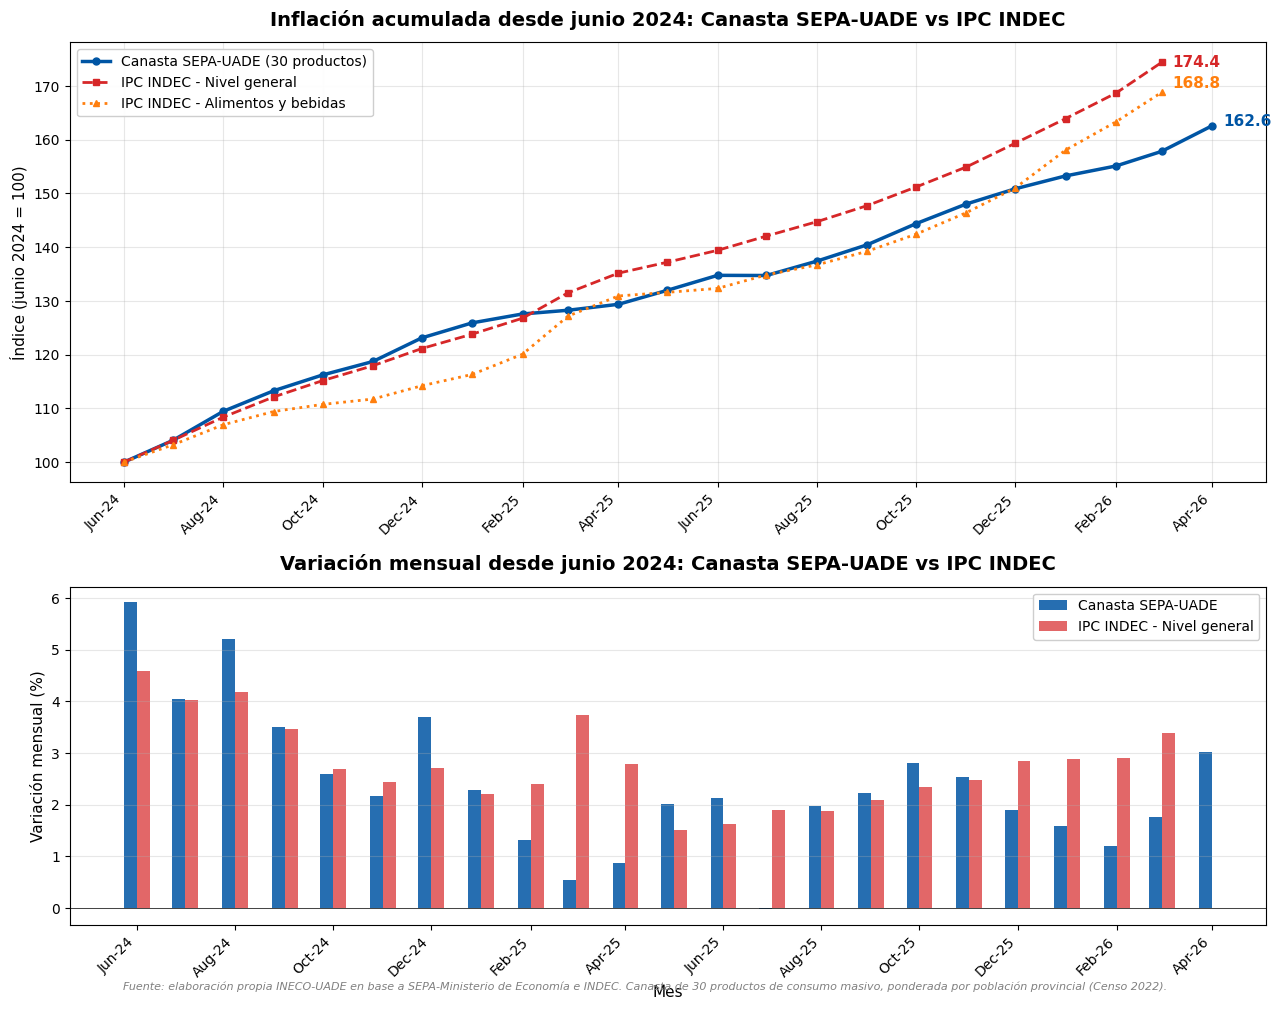


✅ Gráfico guardado en: /content/grafico_canasta_vs_ipc_desde_jun24.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ============================================================
# CELDA 9 — Gráfico filtrado: desde junio 2024 (vista reciente)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Colores institucionales (mismos que celda 8)
COLOR_CANASTA = '#0055A4'
COLOR_IPC_GEN = '#D62728'
COLOR_IPC_ALI = '#FF7F0E'

# Período de análisis para este gráfico
MES_INICIO_GRAFICO = '2024-06'

# Preparar dataframe filtrado
df_g = comparativa[comparativa['mes'] >= MES_INICIO_GRAFICO].copy()
df_g = df_g.sort_values('mes').reset_index(drop=True)
df_g['fecha'] = pd.to_datetime(df_g['mes'] + '-01')

# Reindexar TODO a base 100 = junio 2024 (primer mes del filtro)
base_canasta = df_g['canasta_nacional_ponderada'].iloc[0]
df_g['idx_canasta_jun24'] = (df_g['canasta_nacional_ponderada'] / base_canasta * 100).round(2)

base_ipc_gen = df_g['ipc_general'].iloc[0]
df_g['idx_ipc_general_jun24'] = (df_g['ipc_general'] / base_ipc_gen * 100).round(2)

base_ipc_alim = df_g['ipc_alimentos'].iloc[0]
df_g['idx_ipc_alimentos_jun24'] = (df_g['ipc_alimentos'] / base_ipc_alim * 100).round(2)

print(f"📅 Período del gráfico: desde {df_g['mes'].iloc[0]} hasta {df_g['mes'].iloc[-1]}")
print(f"   {len(df_g)} meses\n")

# ============ FIGURA CON 2 PANELES ============
fig, axes = plt.subplots(2, 1, figsize=(13, 10), gridspec_kw={'height_ratios': [1.3, 1]})

# ---- PANEL 1: ÍNDICES BASE 100 (jun-24 = 100) ----
ax1 = axes[0]
ax1.plot(df_g['fecha'], df_g['idx_canasta_jun24'],
         color=COLOR_CANASTA, linewidth=2.5,
         label='Canasta SEPA-UADE (30 productos)',
         marker='o', markersize=5)
ax1.plot(df_g['fecha'], df_g['idx_ipc_general_jun24'],
         color=COLOR_IPC_GEN, linewidth=2,
         label='IPC INDEC - Nivel general',
         linestyle='--', marker='s', markersize=4)
ax1.plot(df_g['fecha'], df_g['idx_ipc_alimentos_jun24'],
         color=COLOR_IPC_ALI, linewidth=2,
         label='IPC INDEC - Alimentos y bebidas',
         linestyle=':', marker='^', markersize=4)

ax1.set_title('Inflación acumulada desde junio 2024: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Índice (junio 2024 = 100)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Anotar valor final de la canasta (último mes)
ultimo = df_g.iloc[-1]
ax1.annotate(f"{ultimo['idx_canasta_jun24']:.1f}",
             xy=(ultimo['fecha'], ultimo['idx_canasta_jun24']),
             xytext=(8, 0), textcoords='offset points',
             color=COLOR_CANASTA, fontweight='bold', fontsize=11)

# Anotar último valor publicado de IPC
ipc_ultimo = df_g.dropna(subset=['idx_ipc_general_jun24']).iloc[-1]
ax1.annotate(f"{ipc_ultimo['idx_ipc_general_jun24']:.1f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['idx_ipc_general_jun24']),
             xytext=(8, -3), textcoords='offset points',
             color=COLOR_IPC_GEN, fontweight='bold', fontsize=11)
ax1.annotate(f"{ipc_ultimo['idx_ipc_alimentos_jun24']:.1f}",
             xy=(ipc_ultimo['fecha'], ipc_ultimo['idx_ipc_alimentos_jun24']),
             xytext=(8, 3), textcoords='offset points',
             color=COLOR_IPC_ALI, fontweight='bold', fontsize=11)

# ---- PANEL 2: VARIACIONES MENSUALES ----
ax2 = axes[1]
x = df_g['fecha']
width = pd.Timedelta(days=8)

ax2.bar(x - width/2, df_g['variacion_mensual_%'], width=width,
        color=COLOR_CANASTA, alpha=0.85, label='Canasta SEPA-UADE')
ax2.bar(x + width/2, df_g['ipc_general_var_%'], width=width,
        color=COLOR_IPC_GEN, alpha=0.7, label='IPC INDEC - Nivel general')

ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Variación mensual desde junio 2024: Canasta SEPA-UADE vs IPC INDEC',
              fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Variación mensual (%)', fontsize=11)
ax2.set_xlabel('Mes', fontsize=11)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Footer
plt.figtext(0.5, 0.005,
            'Fuente: elaboración propia INECO-UADE en base a SEPA-Ministerio de Economía e INDEC. '
            'Canasta de 30 productos de consumo masivo, ponderada por población provincial (Censo 2022).',
            ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.07)

# Guardar
output_png = '/content/grafico_canasta_vs_ipc_desde_jun24.png'
plt.savefig(output_png, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✅ Gráfico guardado en: {output_png}")
from google.colab import files
files.download(output_png)